# Detetação de Fake News com Text Mining
Projeto para a unidade curricular Text Mining Feito por: Alba Pando Nº123609, André Santos Nº123579, Bruno Oliveira Nº, Filipe Brites Nº123584, Natacha Pulga Nº123656

Este trabalho blah blah text mining blah blah deteção de Fake News

# Instalação de bibliotecas

In [1]:
# Instalar as dependências necessárias do projeto
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importar as bibliotecas necessárias

In [2]:
#Importar bibliotecas
import html
import re
import unicodedata
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from scipy.sparse import hstack, csr_matrix

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix,
    f1_score,
    normalized_mutual_info_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Fazer download dos pacotes necessários do NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Configurações para visualização e warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

# Configura o pandas para não esconder colunas
pd.set_option('display.max_columns', None)

[nltk_data] Downloading package punkt to C:\Users\Big
[nltk_data]     Boss\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Big
[nltk_data]     Boss\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Big
[nltk_data]     Boss\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Carregamento de Dados
Nesta secção fazemos o carregamento dos datasets transferidos através dos CSVs provenientes do Kaggle. Depois do carregamento, removemos linhas duplicadas.

In [3]:
def load_data(path, label, label_name):
    df = pd.read_csv(path)
    
    df["label"] = label
    df["label_name"] = label_name
    return df

#Ler ambos csvs
df_true = load_data("data/True.csv", 0, "true")
df_false = load_data("data/Fake.csv", 1, "fake")

#vamos juntar ambas databases :)
df_total = pd.concat([df_true, df_false], ignore_index=True)

# Preencher valores nulos e garantir que as colunas de texto sejam do tipo string
for column in ["title", "text", "subject", "date"]:
    df_total[column] = df_total[column].fillna("").astype(str)

# Criar a coluna "document" concatenando "title" e "text", e calcular os comprimentos
df_total["document"] = (df_total["title"].str.strip() + ". " + df_total["text"].str.strip()).str.strip()
df_total["title_length"] = df_total["title"].str.split().str.len()
df_total["text_length"] = df_total["text"].str.split().str.len()
df_total["document_length"] = df_total["document"].str.split().str.len()

#randomizing a database para as linhas com diferentes classes estarem mistruradas
df_total = df_total.sample(frac=1).reset_index(drop=True)

# remover duplicados
before = len(df_total)
df_total = df_total.drop_duplicates(subset=["title", "text", "label"]).reset_index(drop=True)
after = len(df_total)

print(f"Documentos antes de remover duplicados: {before}")
print(f"Documentos depois de remover duplicados: {after}")
display(df_total.head())

# export dataframe to csv
df_total.to_csv('data/total.csv', index=False)

Documentos antes de remover duplicados: 44898
Documentos depois de remover duplicados: 39105


,title,text,subject,date,label,label_name,document,title_length,text_length,document_length
0,CNN IS EVIL: Carol Costello FAILS When Benghaz...,"Charles Woods, father of U.S. Navy SEAL Tyrone...",politics,"Aug 5, 2016",1,fake,CNN IS EVIL: Carol Costello FAILS When Benghaz...,13,72,85
1,FEMALE SAILOR FACES DISCIPLINE By US Navy For ...,"***WARNING***If you watch this video, you will...",left-news,"Sep 9, 2016",1,fake,FEMALE SAILOR FACES DISCIPLINE By US Navy For ...,19,154,173
2,Trump Gets ANNIHILATED On Twitter After He Pr...,"On Monday, Donald Trump fulfilled his duty as ...",News,"September 19, 2016",1,fake,Trump Gets ANNIHILATED On Twitter After He Pre...,15,332,347
3,"OBAMA GIVES ILLEGAL ALIENS IN FLINT, MI Amnest...",Because people who scale border walls and brea...,politics,"Mar 4, 2016",1,fake,"OBAMA GIVES ILLEGAL ALIENS IN FLINT, MI Amnest...",16,588,604
4,HERE YOU GO! TRUMP CONDEMNS DAVID DUKE…Calls H...,"Following the situation in Charlottesville, Tr...",politics,"Aug 13, 2017",1,fake,HERE YOU GO! TRUMP CONDEMNS DAVID DUKE…Calls H...,14,178,192


# Análise exploratória dos Dados
Nesta secção vamos realizar uma análise exploratória dos dados obtidos dos CSVs, como realizar análises descritivas dos dados e visualização de algumas distribuições.

In [4]:
# Análise exploratória dos dados - Estatísticas descritivas por classe
dataset_stats = (
    df_total.groupby("label_name")
    .agg(
        documents=("document", "count"),
        unique_subjects=("subject", "nunique"),
        avg_title_words=("title_length", "mean"),
        avg_text_words=("text_length", "mean"),
        median_text_words=("text_length", "median"),
        min_text_words=("text_length", "min"),
        max_text_words=("text_length", "max"),
    )
    .round(2)
)

display(dataset_stats)

,documents,unique_subjects,avg_title_words,avg_text_words,median_text_words,min_text_words,max_text_words
label_name,,,,,,,
fake,17908,6,14.32,414.69,371.0,0,8135
true,21197,2,9.95,384.86,359.0,0,5172


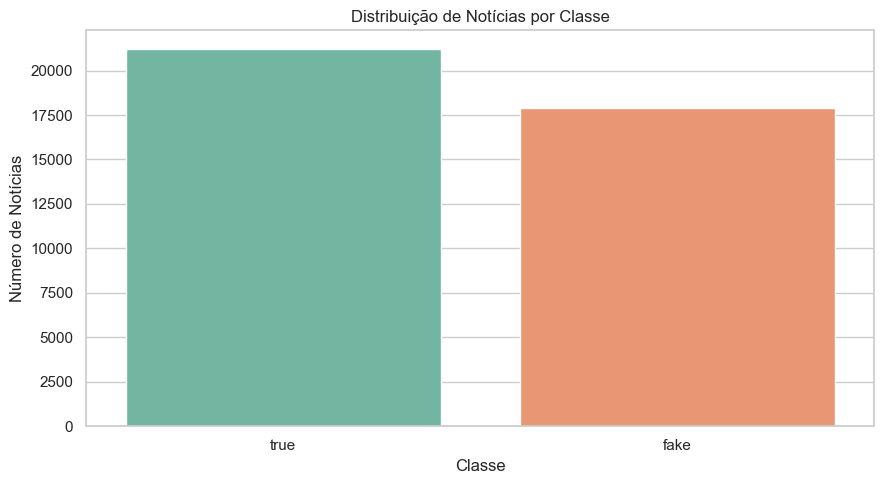

In [5]:
# Visualização da distribuição de notícias por classe
counts = df_total["label_name"].value_counts()
colors = ['#66C2A5', '#FC8D62']

ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
ax.set_title("Distribuição de Notícias por Classe")
ax.set_xlabel("Classe")
ax.set_ylabel("Número de Notícias")
plt.tight_layout()
plt.show()

In [6]:
# Análise da distribuição de notícias por assunto dentro de cada classe
subject_distribution = (
    df_total.groupby(["label_name", "subject"])
    .size()
    .reset_index(name="documents")
    .sort_values(["label_name", "documents"], ascending=[True, False])
)

display(subject_distribution)

,label_name,subject,documents
2,fake,News,9050
5,fake,politics,4600
4,fake,left-news,2545
0,fake,Government News,930
1,fake,Middle-east,417
3,fake,US_News,366
6,true,politicsNews,11207
7,true,worldnews,9990


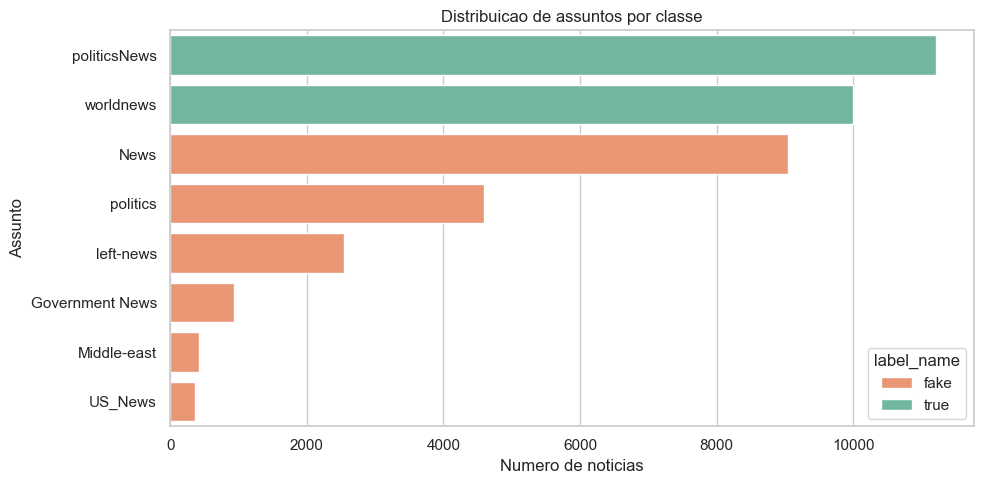

In [7]:
# Visualização da distribuição de assuntos por classe
plt.figure(figsize=(10, 5))
ordered_subjects = subject_distribution.sort_values("documents", ascending=False)["subject"]
ax = sns.countplot(data=df_total, y="subject", order=ordered_subjects, hue="label_name", palette=['#FC8D62', '#66C2A5'])
ax.set_title("Distribuicao de assuntos por classe")
ax.set_xlabel("Numero de noticias")
ax.set_ylabel("Assunto")
plt.tight_layout()
plt.show()

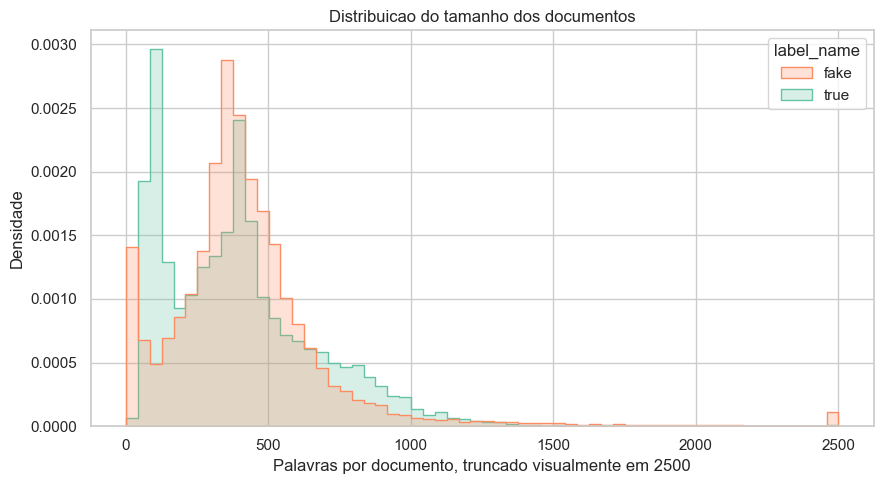

In [8]:
# Visualização da distribuição de tamanho dos documentos por classe
plot_df = df_total.assign(document_length_clipped=df_total["document_length"].clip(upper=2500))
ax = sns.histplot(
    data=plot_df,
    x="document_length_clipped",
    hue="label_name",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
    palette=['#FC8D62', '#66C2A5']
)
ax.set_title("Distribuicao do tamanho dos documentos")
ax.set_xlabel("Palavras por documento, truncado visualmente em 2500")
ax.set_ylabel("Densidade")
plt.tight_layout()
plt.show()

# Pré-processamento dos dados
Nesta secção realizamos o pré-processamento dos dados, aplicando diversas técnicas, como remoção de caracteres especiais e stopwords. 

In [ ]:
# Configurações para limpeza de texto
stop_words = set(stopwords.words('english'))

# Expressões regulares para limpeza de texto
URL_RE = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
EMAIL_RE = re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b")
TWITTER_RE = re.compile(r"@\w+|#\w+")
HTML_TAG_RE = re.compile(r"<[^>]+>")
WHITESPACE_RE = re.compile(r"\s+")
REUTERS_DATELINE_RE = re.compile(
    r"^\s*[A-Z][A-Z\s.,'-]{2,}\s+\(Reuters\)\s*-\s*", flags=re.IGNORECASE
) # Padrão para datelines do Reuters, como "LONDON (Reuters) - " ou "NEW YORK (Reuters) - visto que aparecia muito nos textos"

# Função para remover acentos de um texto
def strip_accents(text):
    normalized = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in normalized if not unicodedata.combining(ch))

def clean_text(text, remove_stopwords = True):
    text = html.unescape(text)
    text = REUTERS_DATELINE_RE.sub("", text)
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" URL ", text)
    text = EMAIL_RE.sub(" EMAIL ", text)
    text = TWITTER_RE.sub(" ", text)
    text = text.replace("\u2019", "'").replace("\u2018", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = strip_accents(text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    tokens = WHITESPACE_RE.sub(" ", text).strip().split()
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    return " ".join(tokens)

In [10]:
# Testar a função de limpeza num exemplo
example = df_total.loc[0, "document"]
print("ANTES:\n", example[:700])
print("\nDEPOIS:\n", clean_text(example)[:700])

ANTES:
 CNN IS EVIL: Carol Costello FAILS When Benghazi Dad Flips Script On Her…#BoycottCNN. Charles Woods, father of U.S. Navy SEAL Tyrone Woods, who was killed during the Benghazi attack, appeared on CNN Tuesday. CNN Newsroom host Carol Costello repeatedly badgered him about Donald Trump s feud with Khizr Khan, and whether Trump should apologize. I know who should apologize, and that would be Hillary Clinton, for lying to the American families who lost their loved ones as well as to the American public,  Woods said.

DEPOIS:
 cnn evil carol costello fails benghazi dad flips script charles woods father navy seal tyrone woods killed benghazi attack appeared cnn tuesday cnn newsroom host carol costello repeatedly badgered donald trump feud khizr khan whether trump apologize know apologize would hillary clinton lying american families lost loved ones well american public woods said


# Preparação para o Treino e Teste
Nesta secção preparamos os dados para serem de teste e treino.

In [11]:
# Aplicar a função de limpeza a toda a coluna "document" e criar uma nova coluna "clean_document"
df_total["clean_document"] = df_total["document"].map(clean_text)

# Dividir os dados em conjuntos de treino e teste, mantendo a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    df_total["clean_document"],
    df_total["label"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_total["label"],
)

print("Treino:", X_train.shape[0])
print("Teste:", X_test.shape[0])
print("Distribuicao no treino:")
print(y_train.value_counts(normalize=True).rename({0: "true", 1: "fake"}))

Treino: 31284
Teste: 7821
Distribuicao no treino:
label
true    0.542066
fake    0.457934
Name: proportion, dtype: float64


# Modelação e Técnicas

## Modelos Supervisionados
Nesta secção defenimos os modelos a utilizar e de seguida analisamos os seus resultados atrvés de métricas de precision e accuracy. 

PERGUNTA: devemos de fazer as explicações aqui?

In [12]:
# Funções para criar os vetorizadores
def make_tfidf_vectorizer():
    return TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        max_features=60000,
        sublinear_tf=True,
    )

def make_bow_vectorizer():
    return CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        max_features=60000,
    )

# Dicionário de modelos a serem testados
models = {
    "BoW + MultinomialNB": Pipeline([
        ("vectorizer", make_bow_vectorizer()),
        ("model", MultinomialNB()),
    ]),
    "TF-IDF + LogisticRegression": Pipeline([
        ("vectorizer", make_tfidf_vectorizer()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "TF-IDF + LinearSVM": Pipeline([
        ("vectorizer", make_tfidf_vectorizer()),
        ("model", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

In [13]:
# Função para avaliar um modelo e calcular métricas principais
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    # Calcular AUC-ROC se o modelo tiver a capacidade de fornecer probabilidades ou scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        result["roc_auc"] = roc_auc_score(y_test, y_score)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        result["roc_auc"] = roc_auc_score(y_test, y_score)
    else:
        result["roc_auc"] = np.nan
    return result

results = []
fitted_models = {}

# Treinar e avaliar cada modelo
for model_name, model in models.items():
    print(f"A treinar: {model_name}")
    model.fit(X_train, y_train)
    results.append(evaluate_model(model, X_test, y_test, model_name))
    fitted_models[model_name] = model

# Criar um DataFrame para comparar os resultados dos modelos
comparison = pd.DataFrame(results).sort_values("f1", ascending=False)
display(comparison)

A treinar: BoW + MultinomialNB
A treinar: TF-IDF + LogisticRegression
A treinar: TF-IDF + LinearSVM


,model,accuracy,precision,recall,f1,roc_auc
2,TF-IDF + LinearSVM,0.993607,0.996346,0.989671,0.992997,0.999640
1,TF-IDF + LogisticRegression,0.987214,0.991530,0.980458,0.985963,0.998993
0,BoW + MultinomialNB,0.960619,0.946779,0.968453,0.957494,0.980428


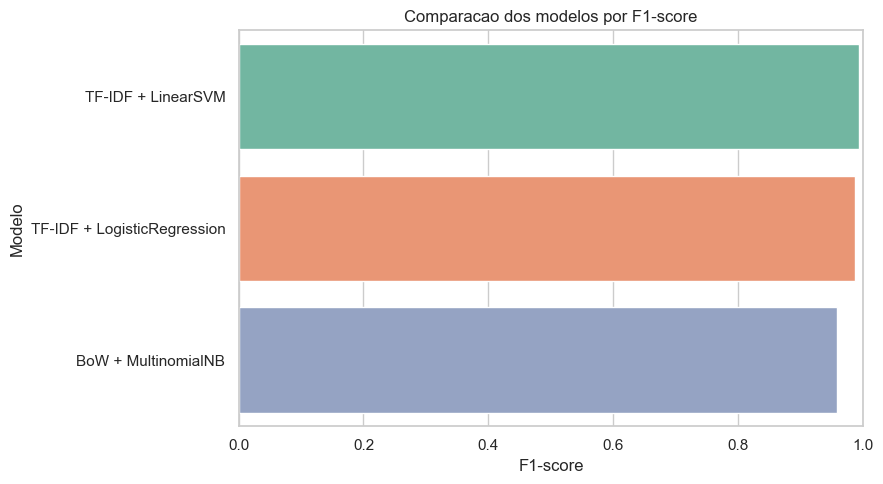

In [14]:
# Visualização comparativa dos modelos por F1-score
ax = sns.barplot(data=comparison, x="f1", y="model", hue="model", legend=False)
ax.set_title("Comparacao dos modelos por F1-score")
ax.set_xlabel("F1-score")
ax.set_ylabel("Modelo")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [15]:
# Análise detalhada do melhor modelo
best_model_name = comparison.iloc[0]["model"]
best_model = fitted_models[best_model_name]
y_pred = best_model.predict(X_test)

print("Melhor modelo:", best_model_name)
print(classification_report(y_test, y_pred, target_names=["true", "fake"], zero_division=0, digits=4))

Melhor modelo: TF-IDF + LinearSVM
              precision    recall  f1-score   support

        true     0.9913    0.9969    0.9941      4239
        fake     0.9963    0.9897    0.9930      3582

    accuracy                         0.9936      7821
   macro avg     0.9938    0.9933    0.9936      7821
weighted avg     0.9936    0.9936    0.9936      7821



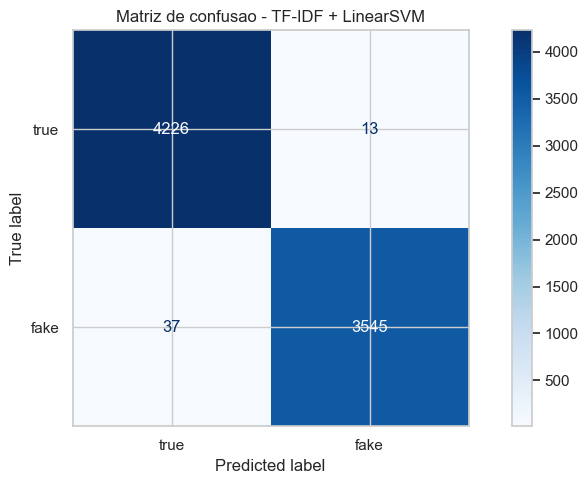

In [16]:
# Matriz de confusão do melhor modelo
matrix = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(matrix, display_labels=["true", "fake"])
display.plot(cmap="Blues", values_format="d")
plt.title(f"Matriz de confusao - {best_model_name}")
plt.tight_layout()
plt.show()

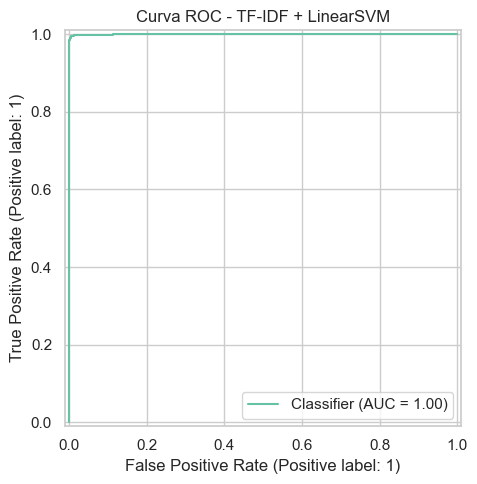

In [17]:
# Curva ROC do melhor modelo
if hasattr(best_model, "predict_proba"):
    RocCurveDisplay.from_predictions(y_test, best_model.predict_proba(X_test)[:, 1])
elif hasattr(best_model, "decision_function"):
    RocCurveDisplay.from_predictions(y_test, best_model.decision_function(X_test))
plt.title(f"Curva ROC - {best_model_name}")
plt.tight_layout()
plt.show()

### Interpretabilidade dos dados
Nesta secção visualiamos que termos tem mais probabilidade em estar numa determinada classe.

In [18]:
# Função para mostrar os termos mais importantes de um modelo linear
def show_linear_terms(pipeline, top_n):
    vectorizer = pipeline.named_steps["vectorizer"] # Acessa o vetor de características do pipeline
    classifier = pipeline.named_steps["model"] # Acessa o modelo de classificação do pipeline
    # Verifica se o modelo tem coeficientes lineares interpretáveis
    terms = np.array(vectorizer.get_feature_names_out())
    coefficients = classifier.coef_[0]

    # Cria DataFrames para os termos mais associados a "fake" e "true", ordenados por peso
    top_fake = pd.DataFrame({
        "term": terms[np.argsort(coefficients)[-top_n:]][::-1],
        "weight": np.sort(coefficients)[-top_n:][::-1],
        "class": "fake",
    })
    top_true = pd.DataFrame({
        "term": terms[np.argsort(coefficients)[:top_n]],
        "weight": np.sort(coefficients)[:top_n],
        "class": "true",
    })
    return pd.concat([top_fake, top_true], ignore_index=True)

# Mostrar os termos mais importantes do modelo linear
linear_model_name = "TF-IDF + LogisticRegression"
if linear_model_name in fitted_models:
    important_terms = show_linear_terms(fitted_models[linear_model_name], top_n=20)
    important_terms.head(10)
else:
    print("Modelo linear nao encontrado.")

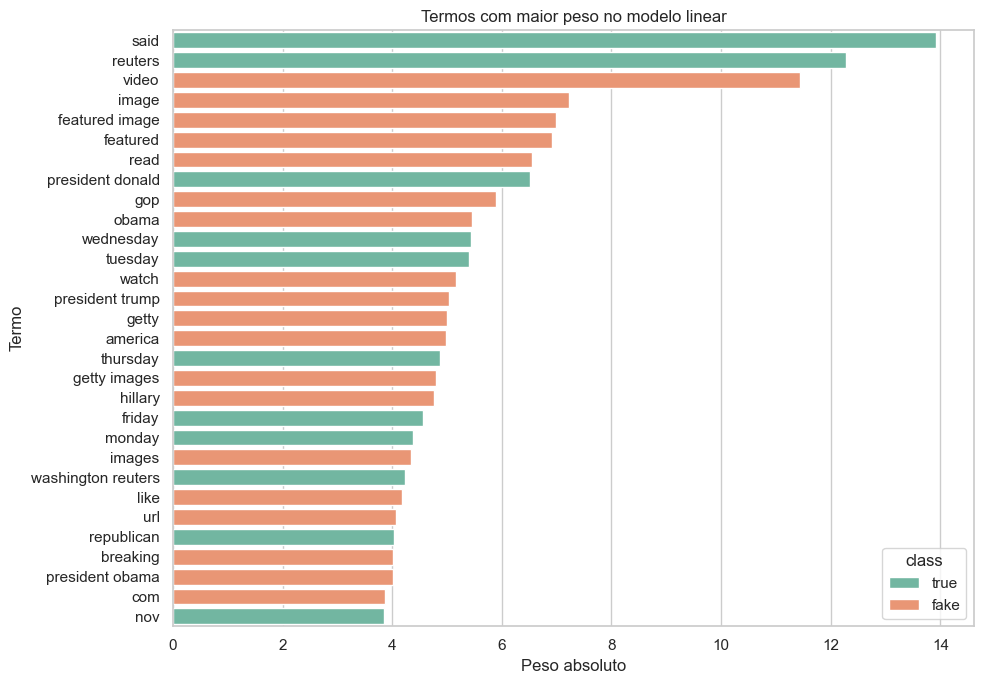

In [19]:
# Visualização dos termos mais importantes do modelo linear
if "important_terms" in globals():
    plt.figure(figsize=(10, 7))
    plot_terms = important_terms.copy()
    plot_terms["abs_weight"] = plot_terms["weight"].abs()
    ax = sns.barplot(
        data=plot_terms.sort_values("abs_weight", ascending=False).head(30),
        x="abs_weight",
        y="term",
        hue="class",
    )
    ax.set_title("Termos com maior peso no modelo linear")
    ax.set_xlabel("Peso absoluto")
    ax.set_ylabel("Termo")
    plt.tight_layout()
    plt.show()

## Recuperação de Informação por Similaridade
Nesta secção fazemos a recupeção da informação por similaridade.

In [20]:
# Usamos uma amostra para a matriz de similaridade nao ficar demasiado pesada.
retrieval_df = df_total.sample(min(len(df_total), 6000), random_state=RANDOM_STATE).reset_index(drop=True)

# Criar um vetor TF-IDF para os documentos e calcular similaridades para um exemplo de consulta
retrieval_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    max_features=30000,
    sublinear_tf=True,
)

# Gerar a matriz TF-IDF para os documentos
tfidf_matrix = retrieval_vectorizer.fit_transform(retrieval_df["clean_document"])
query_index = 0 # Índice do documento de consulta para o qual queremos encontrar os mais similares
similarities = cosine_similarity(tfidf_matrix[query_index], tfidf_matrix).ravel() # Calcula a similaridade do documento de consulta com todos os outros documentos
nearest = similarities.argsort()[::-1][1:6] # Pega os 5 mais similares, ignorando o próprio documento (índice 0)

# Criar um DataFrame para mostrar os exemplos de recuperação
query = retrieval_df.loc[query_index]
retrieval_examples = []
for rank, idx in enumerate(nearest, start=1):
    candidate = retrieval_df.loc[idx]
    retrieval_examples.append({
        "query_title": query["title"],
        "query_label": query["label_name"],
        "rank": rank,
        "similarity": similarities[idx],
        "candidate_title": candidate["title"],
        "candidate_label": candidate["label_name"],
        "candidate_subject": candidate["subject"],
    })

# Mostrar os exemplos de recuperação
retrieval_examples = pd.DataFrame(retrieval_examples)
retrieval_examples

,query_title,query_label,rank,similarity,candidate_title,candidate_label,candidate_subject
0,Trump criticized in Britain and U.S. for shari...,true,1,0.426469,Trump angers UK with truculent tweet to May af...,true,politicsNews
1,Trump criticized in Britain and U.S. for shari...,true,2,0.220806,Leaders of far-right UK group charged with rel...,true,worldnews
2,Trump criticized in Britain and U.S. for shari...,true,3,0.137490,You Won’t Believe The Racist Image Trump Just...,fake,News
3,Trump criticized in Britain and U.S. for shari...,true,4,0.136375,"Under fire, UK's May criticizes Trump curb on ...",true,politicsNews
4,Trump criticized in Britain and U.S. for shari...,true,5,0.132904,Trump complicates travel ban case by grumbling...,true,politicsNews


## Aprendizagem Não Supervisionada
Nesta secção defenimos os modelos a utilizar que prevem

In [21]:
# Clusterização usando KMeans e avaliação dos clusters formados
cluster_df = df_total.sample(min(len(df_total), 10000), random_state=RANDOM_STATE).reset_index(drop=True)
cleaned_docs = cluster_df["clean_document"]

# Criar a matriz TF-IDF para os documentos e reduzir a dimensionalidade com SVD para facilitar a clusterização
cluster_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    max_features=30000,
    sublinear_tf=True,
)
cluster_tfidf = cluster_vectorizer.fit_transform(cleaned_docs)

# Reduzir a dimensionalidade para 100 componentes principais usando SVD
svd = TruncatedSVD(n_components=100, random_state=RANDOM_STATE)
cluster_reduced = svd.fit_transform(cluster_tfidf)

# Aplicar KMeans para formar 2 clusters e avaliar a qualidade dos clusters usando métricas de agrupamento
kmeans = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(cluster_reduced)

# Calcular métricas de avaliação de clusterização comparando os clusters formados com as classes reais
cluster_metrics = {
    "adjusted_rand_index": adjusted_rand_score(cluster_df["label"], clusters),
    "normalized_mutual_info": normalized_mutual_info_score(cluster_df["label"], clusters),
    "svd_explained_variance": svd.explained_variance_ratio_.sum(),
}

# Criar um resumo dos clusters formados, mostrando a contagem de documentos por cluster e classe
cluster_summary = (
    pd.DataFrame({"cluster": clusters, "label_name": cluster_df["label_name"]})
    .value_counts(["cluster", "label_name"])
    .reset_index(name="documents")
    .sort_values(["cluster", "documents"], ascending=[True, False])
)

cluster_metrics, cluster_summary

({'adjusted_rand_index': 0.6291246086504876,
  'normalized_mutual_info': 0.5205442181292164,
  'svd_explained_variance': np.float64(0.12682481596755513)},
    cluster label_name  documents
 1        0       fake       4174
 2        0       true        589
 0        1       true       4792
 3        1       fake        445)

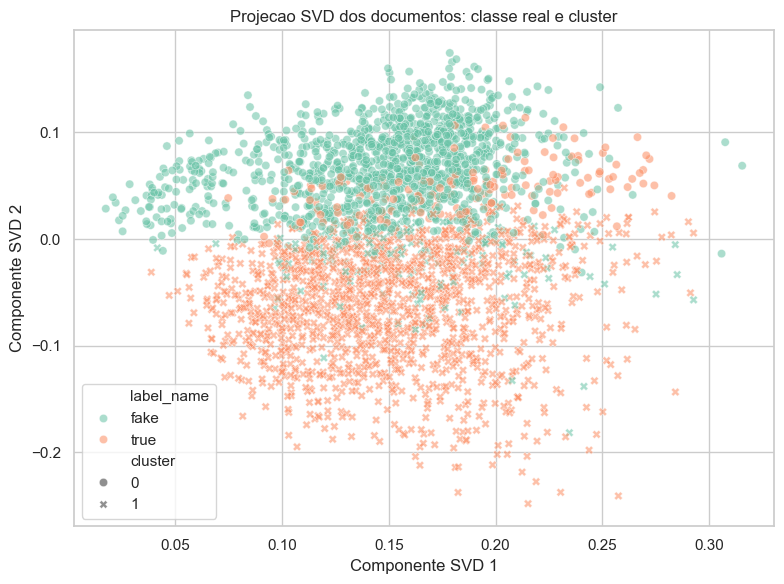

In [22]:
# Visualização da projeção SVD dos documentos, colorida pela classe real e estilo pelo cluster formado
plot_cluster_df = pd.DataFrame({
    "svd_1": cluster_reduced[:, 0],
    "svd_2": cluster_reduced[:, 1],
    "cluster": clusters.astype(str),
    "label_name": cluster_df["label_name"],
})

# Para evitar sobrecarregar a visualização, amostramos um subconjunto dos dados para o scatter plot
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    data=plot_cluster_df.sample(min(len(plot_cluster_df), 3000), random_state=RANDOM_STATE),
    x="svd_1",
    y="svd_2",
    hue="label_name",
    style="cluster",
    alpha=0.55,
)
ax.set_title("Projecao SVD dos documentos: classe real e cluster")
ax.set_xlabel("Componente SVD 1")
ax.set_ylabel("Componente SVD 2")
plt.tight_layout()
plt.show()

# Testar uma Notícia Nova

In [23]:
# Criar um novo documento a partir do título e texto fornecidos, limpar o texto e fazer a previsão usando o melhor modelo
new_title = "Trump says US-Iran ceasefire still in place after exchange of fire in Strait of Hormuz"
new_text = "US President Donald Trump says a ceasefire is still in place with Iran, despite a clash between Iran and US naval destroyers in the Strait of Hormuz for which both sides blamed the other. The US said Iran launched missiles, drones and small boats against three of its warships, in what it called an unprovoked attack. Trump said Iran trifled with us today. Iran's top military command, meanwhile, alleged the US had targeted an Iranian oil tanker and another vessel approaching the Strait of Hormuz and carried out aerial attacks on several coastal areas.The flare-up comes a day after Iran's foreign ministry had said it was considering a US proposal to end the war. In a further sign of the fragility of the ceasefire, early on Friday the United Arab Emirates' Ministry of Defence said its air defences were actively engaging with an missile and drone attack from Iran. Iranian state media initially reported explosions in the Strait of Hormuz, describing them as an exchange of fire with the enemy. Meanwhile, local media reported explosions were heard in Tehran. Not long after, a statement from Iran's top military command said US aerial attacks struck the coasts of Bandar Khamir, Sirik and Qeshm Island. It said it responded immediately by attacking US military vessels, inflicting significant damage, and accused the US of a violation of the ceasefire. US Central Command (Centcom) described the Iranian attacks as unprovoked, saying Iranian forces launched multiple missiles, drones and small boats as US Navy guided-missile destroyers transited through the strait. Centcom said it had eliminated inbound threats and targeted Iranian military facilities responsible for attacking US forces, including missile and drone launch sites; command and control locations; and intelligence, surveillance and reconnaissance nodes. Centcom does not seek escalation but remains positioned and ready to protect American forces, the statement continued. Posting on Truth Social, Trump said that the US had destroyed multiple small boats, missiles and drones, adding that great damage was done to the Iranian attackers. The US president also reiterated a warning over the peace deal: Just like we knocked them out again today, we'll knock them out a lot harder, and a lot more violently, in the future, if they don't get their Deal signed, FAST! An Israeli source told the BBC there was no Israeli involvement in the latest attacks. The increase in tensions comes despite the US president saying in recent days that the war in Iran will be over quickly. US news outlet Axios had said that the White House believes it could be closing in on a 14-point memorandum of understanding with Iran, which could set a framework for more detailed nuclear negotiations. On Wednesday, an Iranian foreign ministry spokesman said the latest US proposal was being considered and that Tehran would share its views with Pakistani mediators. Pakistan's foreign minister said his country was endeavouring to convert this ceasefire into a permanent end to this war. But a senior member of Iran's parliament has dismissed the 14-point memorandum of understanding as a wish list. The spokesperson of the Iranian parliament's national security and foreign policy commission, Ebrahim Rezaei, wrote on X that Iran has its finger on the trigger, warning Iran would deliver a harsh and regret-inducing response if the US did not surrender and grant necessary conditions. Both the US and Iran have threatened an escalation in violence if their respective conditions for a peace deal aren't met. In a Truth Social post on 6 May, Trump wrote that if Iran did not agree to a deal the bombing starts, and it will be, sadly, at a much higher level and intensity than it was before. Trump had previously said Operation Epic Fury - the initial US-Israeli offensive in Iran - would come to an end assuming Iran agrees to give what has been agreed to. Prior to this statement, US Secretary of State Marco Rubio had said the operation was over and had achieved its objectives. Trump also said, not for the first time, that Iran had agreed to never have a nuclear weapon among other things - a claim that has not been confirmed by Tehran. Iran's nuclear programme has been one of the key sticking points between the two sides."

new_document = f"{new_title}. {new_text}"
new_clean_document = clean_text(new_document)
prediction = int(best_model.predict([new_clean_document])[0])
label = "fake" if prediction == 1 else "true"

# Exibir a previsão e, se possível, a confiança do modelo para a previsão
print("Previsão:", label)
if hasattr(best_model, "predict_proba"):
    confidence = best_model.predict_proba([new_clean_document])[0][prediction]
    print(f"Confiança aproximada: {confidence:.3f}")

Previsão: true
